# 10e — Standalone LLM Analysis

Focused analysis of text-only LLMs in the inst_blind condition:
- Scale effect within Qwen3 family (0.6B → 32B)
- Think (chain-of-thought) vs nothink
- Cross-family comparison at similar scale
- Answer diversity and distribution shape
- Human alignment (HM) per model

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

EXPORTS = Path('exports')
PRIMARY  = 'sbert'   # short name (already renamed in pair cache load)
PRIMARY_COL = 'sbert_score_clip'

# Qwen3 scale order (nothink and think)
QWEN3_SCALE = ['Qwen3-0.6B', 'Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-32B']
QWEN3_PARAMS = {'Qwen3-0.6B': 0.6, 'Qwen3-1.7B': 1.7, 'Qwen3-4B': 4,
                'Qwen3-8B': 8, 'Qwen3-32B': 32}

# Cross-family models at comparable scale (~7B)
CROSS_FAMILY = ['Mistral-7B', 'Vicuna-13B', 'Qwen2.5-7B', 'Phi-3.5-mini',
                'Qwen3-8B', 'Qwen3-8B (think)']

COLORS_SCALE  = plt.cm.viridis(np.linspace(0.15, 0.9, 5))
COLOR_THINK   = '#E91E63'
COLOR_NOTHINK = '#1565C0'
COLOR_HH      = '#222222'

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
pairs = pd.read_parquet(EXPORTS / 'pair_cache.parquet')
pairs['sbert'] = pairs[PRIMARY_COL]

m_csv = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')
h_csv = pd.read_csv(EXPORTS / 'responses_human.csv')

llm_models = m_csv[m_csv['model_group'].str.contains('standalone', na=False)]['model'].unique()
llm_csv    = m_csv[m_csv['model'].isin(llm_models)].copy()

# HH reference per question (variant C)
hh_q = (
    pairs[(pairs['pair_type'] == 'HH') & (pairs['variant'] == 'C')]
    .groupby('question_id')['sbert'].mean()
    .rename('hh_mean')
)
hh_global = hh_q.mean()

# HM per model per question (variant C)
hm_C = (
    pairs[
        (pairs['pair_type'] == 'HM') &
        (pairs['variant'] == 'C') &
        (pairs['subject_2'].isin(llm_models))
    ]
    .groupby(['subject_2', 'question_id'])['sbert']
    .mean()
    .reset_index()
    .rename(columns={'subject_2': 'model', 'sbert': 'hm_mean'})
)

model_summary = (
    hm_C.groupby('model')['hm_mean']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'hm_mean', 'std': 'hm_std', 'count': 'n_questions'})
    .reset_index()
)
model_summary['hh_ref']    = hh_global
model_summary['gap_to_hh'] = hh_global - model_summary['hm_mean']
model_summary['is_think']  = model_summary['model'].str.contains('think')
model_summary['params']    = model_summary['model'].str.replace(' \\(think\\)', '', regex=True).map(QWEN3_PARAMS)

print(f'HH global mean (variant C): {hh_global:.3f}')
print(f'\nStandalone LLM summary (sorted by HM alignment):')
display(
    model_summary.sort_values('hm_mean', ascending=False)
    [['model', 'hm_mean', 'hm_std', 'gap_to_hh', 'n_questions']].round(3)
)

HH global mean (variant C): 0.512

Standalone LLM summary (sorted by HM alignment):


,model,hm_mean,hm_std,gap_to_hh,n_questions
2,Qwen2.5-7B,0.473,0.194,0.039,88
11,Qwen3-8B,0.473,0.202,0.040,88
12,Qwen3-8B (think),0.473,0.202,0.040,88
7,Qwen3-32B,0.472,0.194,0.040,67
9,Qwen3-4B,0.448,0.193,0.065,88
10,Qwen3-4B (think),0.448,0.193,0.065,88
8,Qwen3-32B (think),0.396,0.171,0.116,13
5,Qwen3-1.7B,0.366,0.191,0.147,88
3,Qwen3-0.6B,0.354,0.170,0.158,87
4,Qwen3-0.6B (think),0.354,0.170,0.158,87


## 1. Scale effect — Qwen3 nothink vs think

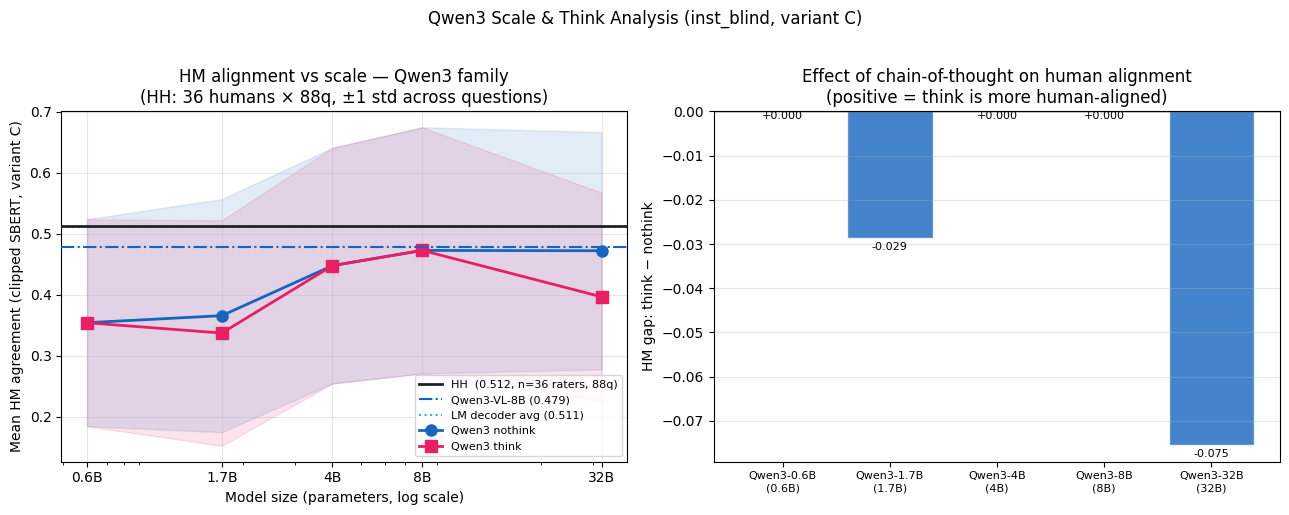

In [3]:
# ── HM alignment vs model scale (Qwen3 family) ───────────────────────────────
# Reference lines: HH baseline, Qwen3-VL-8B (same scale VLM), LM decoder avg

# Pre-compute reference values from pair cache
hh_n_questions = pairs[(pairs["pair_type"]=="HH") & (pairs["variant"]=="C")]["question_id"].nunique()
hh_n_raters    = pd.concat([
    pairs[(pairs["pair_type"]=="HH") & (pairs["variant"]=="C")]["subject_1"],
    pairs[(pairs["pair_type"]=="HH") & (pairs["variant"]=="C")]["subject_2"]
]).nunique()

def group_hm_mean(group_name):
    return pairs[
        (pairs["pair_type"]=="HM") & (pairs["variant"]=="C") &
        (pairs["subject_group_2"]==group_name)
    ]["sbert"].mean()

qwen3vl_hm = pairs[
    (pairs["pair_type"]=="HM") & (pairs["variant"]=="C") &
    (pairs["subject_2"]=="Qwen3-VL-8B")
]["sbert"].mean()

lmd_hm  = group_hm_mean("VLM backbone decoder")
vlm_hm  = group_hm_mean("VLM")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: HM alignment vs scale ──────────────────────────────────────────────
ax = axes[0]

# Reference lines
ax.axhline(hh_global, color=COLOR_HH, lw=2, ls="-",
           label=f"HH  ({hh_global:.3f}, n={hh_n_raters} raters, {hh_n_questions}q)", zorder=5)
ax.axhline(qwen3vl_hm, color="#1565C0", lw=1.5, ls="-.",
           label=f"Qwen3-VL-8B ({qwen3vl_hm:.3f})", zorder=4)
ax.axhline(lmd_hm, color="#42A5F5", lw=1.5, ls=":",
           label=f"LM decoder avg ({lmd_hm:.3f})", zorder=4)

# Nothink and think curves
for mode, color, marker in [("nothink", COLOR_NOTHINK, "o"), ("think", COLOR_THINK, "s")]:
    rows = []
    for base in QWEN3_SCALE:
        label = base if mode == "nothink" else f"{base} (think)"
        sub   = model_summary[model_summary["model"] == label]
        if sub.empty:
            rows.append((QWEN3_PARAMS[base], np.nan, np.nan))
        else:
            rows.append((QWEN3_PARAMS[base], sub["hm_mean"].values[0], sub["hm_std"].values[0]))
    params, means, stds = zip(*rows)
    params = np.array(params, dtype=float)
    means  = np.array(means,  dtype=float)
    stds   = np.array(stds,   dtype=float)
    mask   = ~np.isnan(means)
    ax.plot(params[mask], means[mask], f"{marker}-", color=color, lw=2, ms=8, label=f"Qwen3 {mode}")
    ax.fill_between(params[mask], (means-stds)[mask], (means+stds)[mask], color=color, alpha=0.12)

ax.set_xscale("log")
ax.set_xticks([0.6, 1.7, 4, 8, 32])
ax.set_xticklabels(["0.6B", "1.7B", "4B", "8B", "32B"])
ax.set_xlabel("Model size (parameters, log scale)")
ax.set_ylabel("Mean HM agreement (clipped SBERT, variant C)")
ax.set_title(f"HM alignment vs scale — Qwen3 family\n"
             f"(HH: {hh_n_raters} humans × {hh_n_questions}q, ±1 std across questions)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

# ── Right: think vs nothink gap ───────────────────────────────────────────────
ax = axes[1]
think_gaps = []
for base in QWEN3_SCALE:
    nt = model_summary[model_summary["model"] == base]["hm_mean"]
    th = model_summary[model_summary["model"] == f"{base} (think)"]["hm_mean"]
    if nt.empty or th.empty:
        think_gaps.append((QWEN3_PARAMS[base], np.nan))
    else:
        think_gaps.append((QWEN3_PARAMS[base], th.values[0] - nt.values[0]))

params, gaps = zip(*think_gaps)
gaps = np.array(gaps, dtype=float)
colors = [COLOR_THINK if (not np.isnan(g) and g > 0) else COLOR_NOTHINK for g in gaps]
bars = ax.bar(range(len(QWEN3_SCALE)), gaps, color=colors, alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", lw=1)
ax.set_xticks(range(len(QWEN3_SCALE)))
ax.set_xticklabels([f"{s}\n({p}B)" for s, p in zip(QWEN3_SCALE, [0.6,1.7,4,8,32])], fontsize=8)
ax.set_ylabel("HM gap: think − nothink")
ax.set_title("Effect of chain-of-thought on human alignment\n(positive = think is more human-aligned)")
ax.grid(axis="y", alpha=0.3)
for bar, g in zip(bars, gaps):
    if not np.isnan(g):
        ax.text(bar.get_x() + bar.get_width()/2, g + 0.001 * np.sign(g),
                f"{g:+.3f}", ha="center", va="bottom" if g > 0 else "top", fontsize=8)

plt.suptitle("Qwen3 Scale & Think Analysis (inst_blind, variant C)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 2. Cross-family comparison

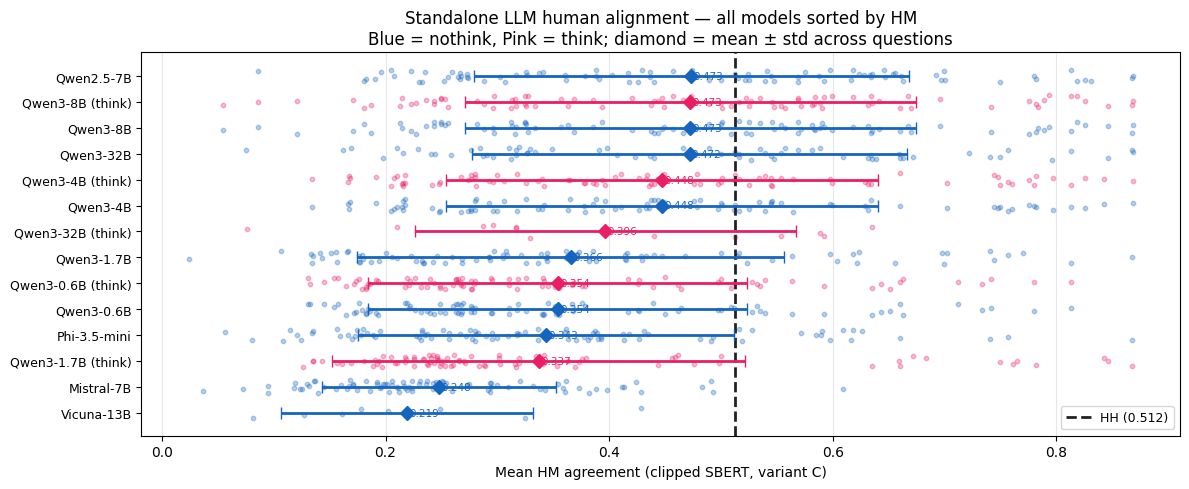

In [4]:
# ── All standalone LLMs: jitter + mean ± std, sorted by HM ───────────────────
plot_order = (
    model_summary
    .sort_values('hm_mean', ascending=True)
    ['model'].tolist()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvline(hh_global, color=COLOR_HH, lw=2, ls='--', label=f'HH ({hh_global:.3f})', zorder=5)

for yi, model in enumerate(plot_order):
    sub    = hm_C[hm_C['model'] == model]['hm_mean'].dropna()
    is_think = '(think)' in model
    color  = COLOR_THINK if is_think else COLOR_NOTHINK
    jitter = np.random.uniform(-0.25, 0.25, len(sub))
    ax.scatter(sub, yi + jitter, s=10, alpha=0.3, color=color, zorder=2)
    ax.errorbar(sub.mean(), yi, xerr=sub.std(),
                fmt='D', color=color, ms=7, lw=2, capsize=4, zorder=6)
    ax.text(sub.mean() + 0.002, yi+0.002, f'{sub.mean():.3f}',
            va='center', fontsize=7.5, color=color)

ax.set_yticks(range(len(plot_order)))
ax.set_yticklabels(plot_order, fontsize=9)
ax.set_xlabel('Mean HM agreement (clipped SBERT, variant C)')
ax.set_title('Standalone LLM human alignment — all models sorted by HM\n'
             'Blue = nothink, Pink = think; diamond = mean ± std across questions')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Answer diversity

,model,n_answers,n_unique,pct_unique,entropy
14,HUMAN (reference),4067,1038,0.255,7.418
0,Mistral-7B,113,112,0.991,6.802
1,Phi-3.5-mini,113,109,0.965,6.732
3,Qwen3-0.6B,112,94,0.839,6.461
4,Qwen3-0.6B (think),112,94,0.839,6.461
6,Qwen3-1.7B (think),112,95,0.848,6.292
11,Qwen3-8B,113,87,0.770,6.094
12,Qwen3-8B (think),113,87,0.770,6.094
5,Qwen3-1.7B,113,88,0.779,5.948
2,Qwen2.5-7B,113,76,0.673,5.726


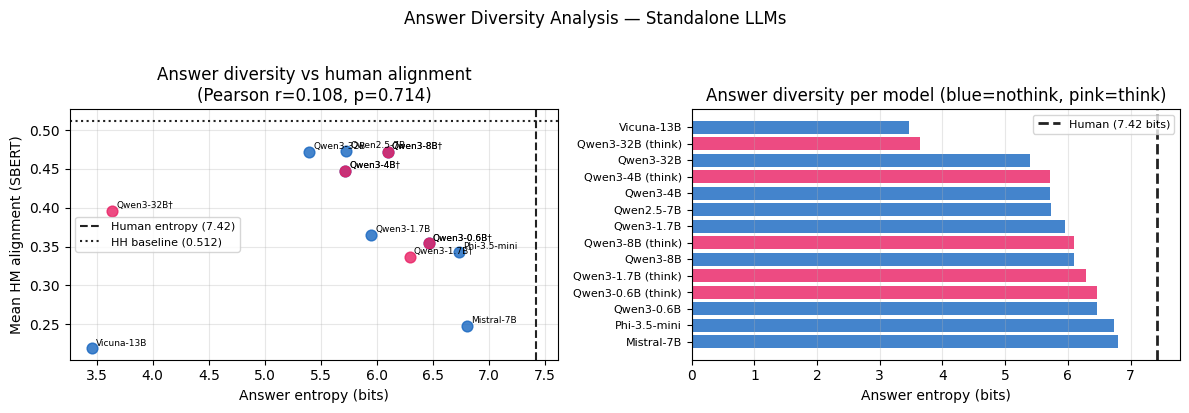

In [5]:
# ── Answer diversity per model: unique answers, entropy ───────────────────────
# Repetitive models (low entropy) tend to be less human-like.
# Compute over variant C only.

def answer_entropy(answers):
    counts = Counter(answers)
    total  = sum(counts.values())
    probs  = np.array([v / total for v in counts.values()])
    return -np.sum(probs * np.log2(probs + 1e-12))

C_llm = llm_csv[llm_csv['variant'] == 'C']
C_hum = h_csv[h_csv['variant'] == 'C'] if 'variant' in h_csv.columns else h_csv

div_rows = []
for model, grp in C_llm.groupby('model'):
    answers = grp['response'].dropna().str.lower().str.strip().tolist()
    div_rows.append({
        'model':       model,
        'n_answers':   len(answers),
        'n_unique':    len(set(answers)),
        'pct_unique':  len(set(answers)) / max(len(answers), 1),
        'entropy':     answer_entropy(answers),
        'is_think':    '(think)' in model,
    })

# Human reference
h_answers = C_hum['response'].dropna().str.lower().str.strip().tolist()
div_rows.append({
    'model': 'HUMAN (reference)', 'n_answers': len(h_answers),
    'n_unique': len(set(h_answers)), 'pct_unique': len(set(h_answers)) / max(len(h_answers), 1),
    'entropy': answer_entropy(h_answers), 'is_think': False,
})

div_df = pd.DataFrame(div_rows).sort_values('entropy', ascending=False)
display(div_df[['model', 'n_answers', 'n_unique', 'pct_unique', 'entropy']].round(3))

# Plot entropy vs HM alignment
merged_div = div_df[div_df['model'] != 'HUMAN (reference)'].merge(
    model_summary[['model', 'hm_mean']], on='model', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for _, row in merged_div.iterrows():
    color = COLOR_THINK if row['is_think'] else COLOR_NOTHINK
    ax.scatter(row['entropy'], row['hm_mean'], s=60, color=color, alpha=0.8, zorder=3)
    ax.annotate(row['model'].replace(' (think)', '†'), (row['entropy'], row['hm_mean']),
                fontsize=6.5, xytext=(3, 2), textcoords='offset points')
h_ent = div_df[div_df['model'] == 'HUMAN (reference)']['entropy'].values[0]
ax.axvline(h_ent, color=COLOR_HH, ls='--', lw=1.5, label=f'Human entropy ({h_ent:.2f})')
ax.axhline(hh_global, color=COLOR_HH, ls=':', lw=1.5, label=f'HH baseline ({hh_global:.3f})')
r, p = stats.pearsonr(merged_div['entropy'].dropna(), merged_div['hm_mean'].dropna())
ax.set_xlabel('Answer entropy (bits)')
ax.set_ylabel('Mean HM alignment (SBERT)')
ax.set_title(f'Answer diversity vs human alignment\n(Pearson r={r:.3f}, p={p:.3f})')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
plot_models = div_df[div_df['model'] != 'HUMAN (reference)']['model'].tolist()
entropies = [div_df[div_df['model']==m]['entropy'].values[0] for m in plot_models]
colors = [COLOR_THINK if '(think)' in m else COLOR_NOTHINK for m in plot_models]
bars = ax.barh(range(len(plot_models)), entropies, color=colors, alpha=0.8)
ax.axvline(h_ent, color=COLOR_HH, ls='--', lw=2, label=f'Human ({h_ent:.2f} bits)')
ax.set_yticks(range(len(plot_models)))
ax.set_yticklabels(plot_models, fontsize=8)
ax.set_xlabel('Answer entropy (bits)')
ax.set_title('Answer diversity per model (blue=nothink, pink=think)')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)

plt.suptitle('Answer Diversity Analysis — Standalone LLMs', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Per-question analysis: where do LLMs agree/disagree with humans?

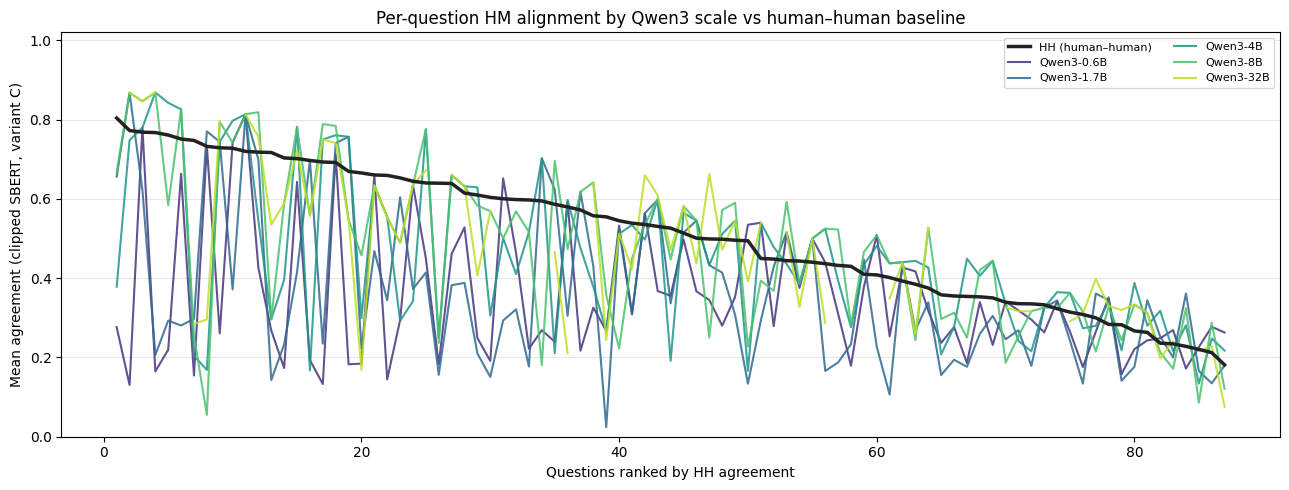

── Questions where LLMs are MOST misaligned with humans (largest HH−HM gap) ──


,question_en,hh_mean,mean_llm_hm,gap_hh_llm
18,How many train track are there?,0.747,0.239,0.508
19,How many railway track are there?,0.747,0.239,0.508
20,How many are there?,0.747,0.239,0.508
75,How many kids have glasses?,0.639,0.206,0.433
76,How many children have glasses?,0.639,0.206,0.433
77,How many have glasses?,0.639,0.206,0.433
36,How many of these people are female?,0.717,0.308,0.409
37,How many of the people are female?,0.717,0.308,0.409



── Questions where LLMs are CLOSEST to humans ──


,question_en,hh_mean,mean_llm_hm,gap_hh_llm
30,What color of wine is in the glasses?,0.720,0.813,-0.094
31,What color of beverage is in the glasses?,0.720,0.813,-0.094
32,What color of it is in them?,0.720,0.813,-0.094
156,What type of computer is the cat using?,0.444,0.514,-0.070
157,What type of device is the cat using?,0.444,0.514,-0.070
158,What type is it using?,0.444,0.514,-0.070
162,What kind of animal is shown on this piece of ...,0.440,0.500,-0.060
163,What kind of animal is shown on the piece of art?,0.440,0.500,-0.060


In [6]:
# ── Per-question HM for each Qwen3 scale vs HH ───────────────────────────────
qwen_nothink = [m for m in QWEN3_SCALE if m in hm_C['model'].unique()]

q_wide = hh_q.reset_index().rename(columns={'question_id': 'question_id'})
for model in qwen_nothink:
    sub = hm_C[hm_C['model'] == model][['question_id', 'hm_mean']]
    sub = sub.rename(columns={'hm_mean': model})
    q_wide = q_wide.merge(sub, on='question_id', how='left')

q_wide = q_wide.dropna(subset=['hh_mean'] + qwen_nothink[:2]).copy()
q_wide = q_wide.sort_values('hh_mean', ascending=False).reset_index(drop=True)
q_wide['rank'] = np.arange(1, len(q_wide) + 1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(q_wide['rank'], q_wide['hh_mean'], color=COLOR_HH, lw=2.5, label='HH (human–human)', zorder=5)
for i, model in enumerate(qwen_nothink):
    if model in q_wide.columns:
        color = COLORS_SCALE[i]
        ax.plot(q_wide['rank'], q_wide[model], lw=1.5, color=color,
                alpha=0.85, label=model)

ax.set_xlabel('Questions ranked by HH agreement')
ax.set_ylabel('Mean agreement (clipped SBERT, variant C)')
ax.set_title('Per-question HM alignment by Qwen3 scale vs human–human baseline')
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

# Questions where LLMs are most/least aligned with humans
q_wide['mean_llm_hm'] = q_wide[qwen_nothink].mean(axis=1)
q_wide['gap_hh_llm']  = q_wide['hh_mean'] - q_wide['mean_llm_hm']

# Add question text
q_text = pairs[['question_id','question_en']].drop_duplicates()
q_wide = q_wide.merge(q_text, on='question_id', how='left')

from IPython.display import display
print('── Questions where LLMs are MOST misaligned with humans (largest HH−HM gap) ──')
display(q_wide.nlargest(8, 'gap_hh_llm')[['question_en','hh_mean','mean_llm_hm','gap_hh_llm']].round(3))

print('\n── Questions where LLMs are CLOSEST to humans ──')
display(q_wide.nsmallest(8, 'gap_hh_llm')[['question_en','hh_mean','mean_llm_hm','gap_hh_llm']].round(3))

## 5. Language prior fingerprint

For each question, we can compute how much of the human answer distribution is **explained by the LLM language prior**.
Questions where LLM ≈ human (small gap) are driven by language priors; questions where LLM ≠ human require vision.

This decomposition can serve as a **shortcut detector**: if a VLM answers like the LLM (not like humans who saw the image), it is exploiting the language prior rather than using visual information.

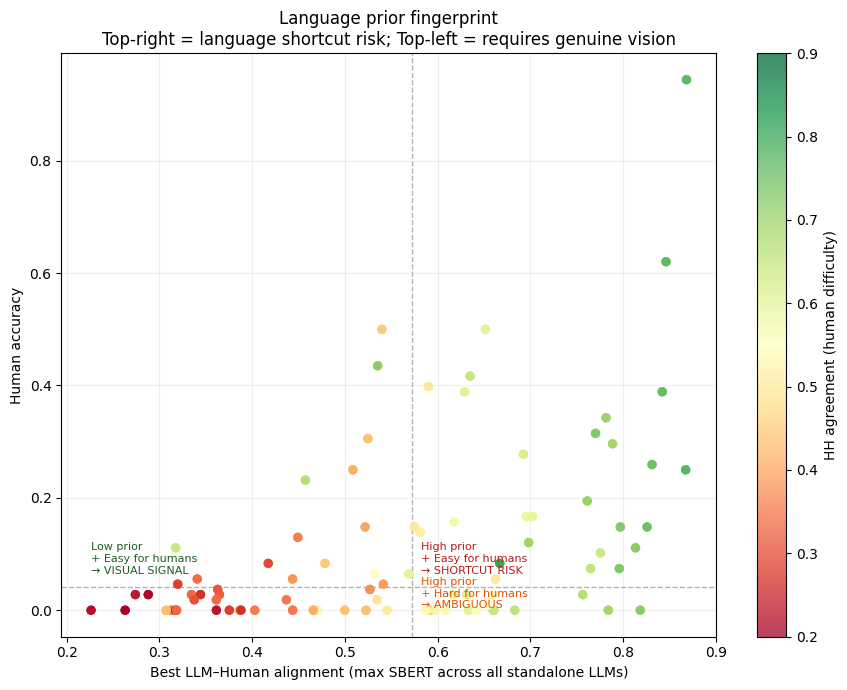

Pearson r (best LLM HM vs human accuracy): r=0.456  p=0.000


In [7]:
# ── Language prior score: how much does the best LLM predict human answers? ───
# For each question, take the highest-HM standalone LLM as the "prior oracle".
# Compare: human accuracy vs LLM HM alignment.
# Questions in the top-right (high accuracy AND high LLM alignment) = language-prior shortcuts.
# Questions in the top-left (high accuracy AND low LLM alignment) = genuine vision signal.

# Best LLM per question = max HM across all standalone LLM models
best_llm_hm = (
    hm_C.groupby('question_id')['hm_mean']
    .max()
    .rename('best_llm_hm')
    .reset_index()
)

human_acc = (
    h_csv.groupby('question_id')['human_avg_acc']
    .first()
    .rename('human_acc')
    .reset_index()
)

fingerprint = (
    best_llm_hm
    .merge(hh_q.reset_index(), on='question_id', how='inner')
    .merge(human_acc, on='question_id', how='left')
    .merge(q_text, on='question_id', how='left')
)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    fingerprint['best_llm_hm'],
    fingerprint['human_acc'],
    c=fingerprint['hh_mean'],
    cmap='RdYlGn', vmin=0.2, vmax=0.9,
    s=45, alpha=0.75, edgecolors='none', zorder=3
)
plt.colorbar(sc, ax=ax, label='HH agreement (human difficulty)')

# Quadrant lines
ax.axvline(fingerprint['best_llm_hm'].median(), color='gray', ls='--', lw=1, alpha=0.6)
ax.axhline(fingerprint['human_acc'].median(),    color='gray', ls='--', lw=1, alpha=0.6)

# Quadrant labels
xm = fingerprint['best_llm_hm'].median()
ym = fingerprint['human_acc'].median()
ax.text(xm + 0.01, ym + 0.02, 'High prior\n+ Easy for humans\n→ SHORTCUT RISK',
        fontsize=8, color='#B71C1C', va='bottom')
ax.text(fingerprint['best_llm_hm'].min(), ym + 0.02, 'Low prior\n+ Easy for humans\n→ VISUAL SIGNAL',
        fontsize=8, color='#1B5E20', va='bottom')
ax.text(xm + 0.01, fingerprint['human_acc'].min(), 'High prior\n+ Hard for humans\n→ AMBIGUOUS',
        fontsize=8, color='#E65100', va='bottom')

ax.set_xlabel('Best LLM–Human alignment (max SBERT across all standalone LLMs)')
ax.set_ylabel('Human accuracy')
ax.set_title('Language prior fingerprint\n'
             'Top-right = language shortcut risk; Top-left = requires genuine vision')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(fingerprint['best_llm_hm'].dropna(),
                       fingerprint.loc[fingerprint['best_llm_hm'].notna(), 'human_acc'])
print(f'Pearson r (best LLM HM vs human accuracy): r={r:.3f}  p={p:.3f}')